In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error,r2_score

В данном блоке подключаются необходимые библиотеки для работы с данными (pandas, numpy) и их визуализации (matplotlib, seaborn). Из библиотеки sclearn импортируются модули, которые понадобятся для разделения выборки, масштабирования признаков, обучения модели k-ближайших соседей, вычисления Гауссовского ядра (для регрессии Надарая-Ватсона) и расчета MAE и R2.

1. Загузка и Разведочный анализ

In [2]:
df = pd.read_csv("used_car_price_dataset_extended.csv")

print(f"Размеры таблицы: {df.shape[0]} автомобилей и {df.shape[1]} параметров")

price_by_brand = df.groupby("brand")["price_usd"].median().sort_values(ascending=False)
price_by_fuel = df.groupby("fuel_type")["price_usd"].median().sort_values(ascending=False)

print("\nСредняя цена перепродажи ($) в зависимости от бренда авто: \n", price_by_brand)
print("\nСредняя цена перепродажи ($) в зависимости от типа топлива: \n", price_by_fuel)

df.head(3)

Размеры таблицы: 10000 автомобилей и 12 параметров

Средняя цена перепродажи ($) в зависимости от бренда авто: 
 brand
BMW           7154.850
Ford          7054.810
Honda         7051.430
Volkswagen    7015.750
Toyota        6982.410
Nissan        6942.140
Chevrolet     6881.840
Kia           6876.330
Hyundai       6849.340
Tesla         6815.735
Name: price_usd, dtype: float64

Средняя цена перепродажи ($) в зависимости от типа топлива: 
 fuel_type
Electric    9684.73
Diesel      6754.22
Petrol      6673.44
Name: price_usd, dtype: float64


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes


Группировка по брендам автомобилей: разброс средних цен между брендами небольшой - от 6815 до 7155 долларов, разница составляет около 340 долларов. Можно сделать вывод, что в данном датасете бренд слабо влияет на цену перепродажи, цена сильнее зависит от других показателей - года выпуска, пробега, комплектации и тд.

Группировка по типу топлива: электромобили стоят значительно дороже по сравнению с дизелем и бензином. Разница составляет около 3000 долларов. Автомобили с дизелем и бензином практически равнозначны по цене.


2. Подготовка признаков

In [3]:
df = pd.get_dummies(df, drop_first=True)
df.head(3)

X = df.drop('price_usd', axis=1)
Y = df['price_usd']

X_train, X_test, Y_train, Y_test= train_test_split(X, Y, train_size=0.8, random_state=42)

number_cols = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count',  'accidents_reported']
scaler = StandardScaler()
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

X_train.head(3)

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,brand_Ford,brand_Honda,...,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Partial,insurance_valid_Yes
9254,-0.860884,-1.644253,-0.379682,-0.705460,-0.703197,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
1561,-0.622453,-0.368146,-0.612288,-0.000793,-0.703197,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1670,-0.503238,-1.482746,2.101455,-0.705460,-0.703197,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False


Выполнена подготовка числовых признаков для обучения модели. Исходный набор данных был разделен на тренировочную (80%) и тестовую (20%) выборки. Для числовых признаков выполнено масштабирование, приводящее значения к единому масштабу. Параметры масштабирования рассчитаны на тренировочной выборке, чтобы предотвратить утечку информации из теста и обеспечить корректную оценку модели.

3. Поиск оптимального числа соседей

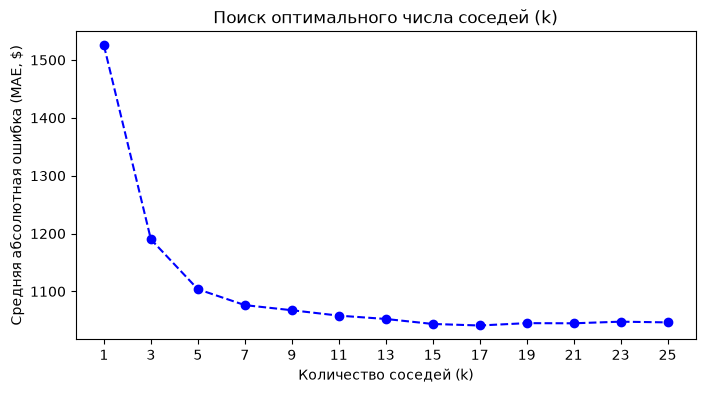

In [4]:
errors = []
k_values = range(1, 26, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(Y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей (k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка (MAE, $)")
plt.xticks(k_values)
plt.show()

Построен график зависимости ошибки (MAE) от числа соседей k.

Вывод: При k=1 ошибка максимальна и составляет ~1,525 долларов. Модель в этом случае слишком чувствительна к выбросам, это приводит к высокой ошибке на тестовых данных, т.е. к переобучению. С ростом k ошибка падает: при k=3 она снижается до ~1,190, а при k=5 до ~1100. На графике виден первый излом в районе k=3 и второй излом в районе k=5. При k>7 кривая снижается очень медленно. Дальнейшее увеличение числа соседей не дает существенного выигрыша в точности, модель начинает усреднять цены по слишком широкому кругу автомобилей, игнорируя их индивидуальные различия (недообучение).

Оптимальное число соседей k - 5, поскольку модель уже избавилась от сильной чувствительности к выбросам (как при k=1), но еще не начала излишне усреднять данные (как при k>15).

4. Сравнение метрик расстояния Минковского

In [5]:
best_k = 5
#Обучаем модель с Евклидовой метрикой p=2
knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, Y_train)
y_pred_euc = knn_euclidean.predict(X_test)

#Обучаем модель с Манхэттенской метрикой p=1
knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, Y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = ${mean_absolute_error(Y_test, y_pred_euc):,.2f} | R2 = {r2_score(Y_test, y_pred_euc):,.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(Y_test, y_pred_man):,.2f} | R2 = {r2_score(Y_test, y_pred_man):,.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $1,103.79 | R2 = 0.75
Манхэттенское расстояние (p=1): MAE = $1,156.94 | R2 = 0.73


Евклидово расстояние показало себя лучше - ошибка MAE на ~53 доллара ниже, точность р2 на 0.02 выше.

5. Регрессия Надарая-Ватсона

In [6]:
gamma_values = np.logspace(-2, 1, 30)

best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for gamma in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=gamma)
    weights_normalized = weights / weights.sum(axis=1, keepdims=True)

    y_pred_nw = np.dot(weights_normalized, Y_train.values)
    r2 = r2_score(Y_test, y_pred_nw)
    mae = mean_absolute_error(Y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = gamma

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальный gamma: {best_gamma:.2f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")

gamma_values = np.logspace(-2, 1, 30)


=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 1.49
Лучшее R2: 0.77
Лучшее MAE: $1063.84


Ядерная регрессия показала наилучший результат среди всех протестированных методов: точность 0.77 и ошибка MAE 1063.84 доллара. 

6. Визуализация

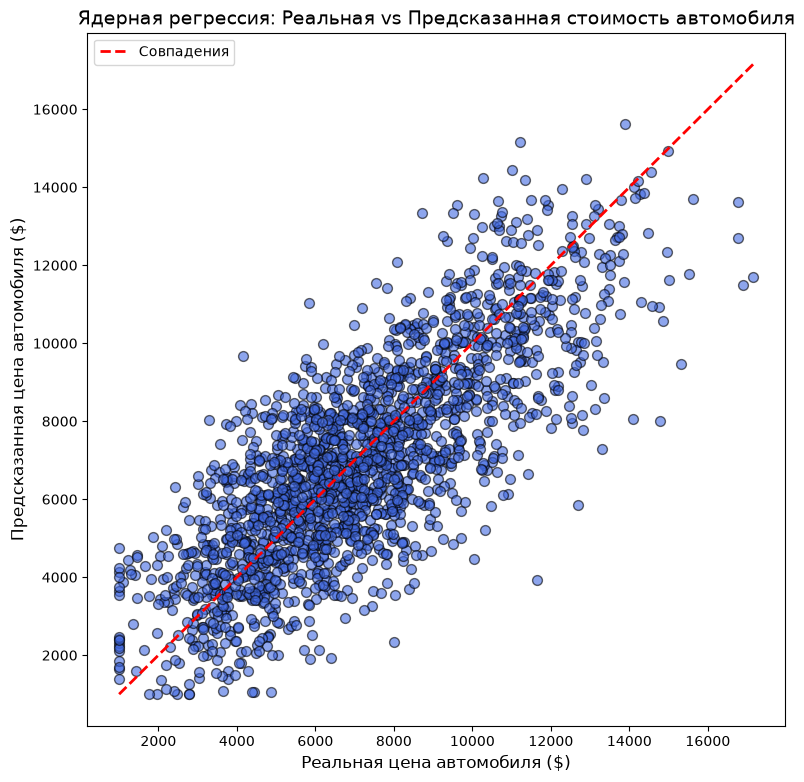

In [7]:
plt.figure(figsize=(9,9))

plt.scatter(Y_test, y_pred_nw, alpha=0.6, color="royalblue", edgecolor="k", s=50)

max_val = max(Y_test.max(), y_pred_nw.max())
min_val = min(Y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Совпадения"
)

plt.title("Ядерная регрессия: Реальная vs Предсказанная стоимость автомобиля", fontsize=14)
plt.xlabel("Реальная цена автомобиля ($)", fontsize=12)
plt.ylabel("Предсказанная цена автомобиля ($)", fontsize=12)
plt.legend()
plt.show()

На графике видно, что предсказания ядерной регрессии следуют за линией совпадения, что подтверждает способность модели улавливать зависимость между характеристиками автомобиля и его ценой.

В среднем ценовом диапазоне (от 4000 до 12000 долларов) точки плотно группируются вокруг диагонали - здесь модель работает наиболее точно. По краям (дешевые авто до 3000 и дорогие от 14000 долларов) разброс увеличивается, что указывает на меньшую уверенность модели. Также присутствуют выбросы - отдельные автомобили, чья реальная цена значительно отклоняется от предсказанной.

Модель демонстрирует хорошее качество предсказания (77%). Средняя ошибка ~1064 долларов при средней стоимости авто ~7000 долларов составляет около 15%, что приемлемо для автоматической оценки стоимости автомобиля.

Модель может быть использована как инструмент предварительной оценки стоимости подержанных автомобилей:
- На онлайн-площадках (Авто.ру, Авито) для рекомендации продавцам рыночной цены на основе введенных параметров авто
- В автосалонах при приеме автомобилей в trade-in для объективной и мгновенной оценки
- В банках и страховых компаниях для оценки залоговой стоимости при автокредитовании и расчета страховых выплат